# ASB Evaluation Dashboard

Read raw experiment CSV files for each defense (baseline, llama_guard, llm_guard, SafeAgent)
and each scenario (benign, DPI, IPI, MP), then compute:

- **ASR / PNA** with 95% Wilson confidence intervals
- **Paired Bootstrap** 95% CI for SafeAgent vs others
- **Exact McNemar** test with Holm-Bonferroni correction

All numbers are computed directly from the raw CSV files.

In [14]:
import hashlib
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Tuple
from scipy.stats import binom

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'font.size': 12, 'figure.dpi': 130})

In [15]:
# ============================================================
# Data paths
# ============================================================
DATA_ROOT = Path("../outputs/main_result/ASB")
DEFENSES = ["baseline", "llama_guard", "llm_guard", "SafeAgent"]
SCENARIOS = ["benign", "DPI", "IPI", "MP"]

# Read all raw CSVs into a dict: result[(defense, scenario)] = DataFrame
result = {}
for d in DEFENSES:
    for s in SCENARIOS:
        path = DATA_ROOT / d / f"{s}.csv"
        if path.exists():
            df = pd.read_csv(path)
            df = df[df['status'] == 'ok'].copy() if 'status' in df.columns else df
            result[(d, s)] = df
            print(f"  [{d:<15} {s:<8}] {len(df):>5} cases")
        else:
            print(f"  [{d:<15} {s:<8}] MISSING")

print(f"\nLoaded {len(result)} files")

  [baseline        benign  ]    51 cases
  [baseline        DPI     ]  2040 cases
  [baseline        IPI     ]  2040 cases
  [baseline        MP      ]  2040 cases
  [llama_guard     benign  ]    51 cases
  [llama_guard     DPI     ]  2040 cases
  [llama_guard     IPI     ]  2040 cases
  [llama_guard     MP      ]  2040 cases
  [llm_guard       benign  ]    51 cases
  [llm_guard       DPI     ]  2040 cases
  [llm_guard       IPI     ]  2040 cases
  [llm_guard       MP      ]  2040 cases
  [SafeAgent       benign  ]    51 cases
  [SafeAgent       DPI     ]  2040 cases
  [SafeAgent       IPI     ]  2040 cases
  [SafeAgent       MP      ]  2040 cases

Loaded 16 files


In [16]:
# ============================================================
# Wilson score interval
# ============================================================
def wilson_ci(count: int, n: int, z: float = 1.96):
    if n == 0:
        return (0.0, 0.0)
    p = count / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return (centre - margin, centre + margin)


def fmt_val(rate, lo, hi):
    return f"{rate:.4f} [{lo:.4f}, {hi:.4f}]"


print("Wilson CI functions loaded")

Wilson CI functions loaded


In [17]:
# ============================================================
# Per-file statistics: ASR (attack) and PNA (benign)
# ============================================================
rows = []
for d in DEFENSES:
    for s in SCENARIOS:
        df = result.get((d, s))
        if df is None or len(df) == 0:
            continue
        col = "task_ok" if s == "benign" else "attack_ok"
        metric = "PNA" if s == "benign" else "ASR"
        n = len(df)
        successes = int(df[col].sum())
        rate = successes / n
        lo, hi = wilson_ci(successes, n)
        rows.append({
            'defense': d,
            'scenario': s,
            'metric': metric,
            'N': n,
            'rate': rate,
            'CI_lower': lo,
            'CI_upper': hi,
            'display': fmt_val(rate, lo, hi),
        })

stats = pd.DataFrame(rows)
print(f"Computed {len(stats)} metric rows")

Computed 16 metric rows


In [18]:
# ============================================================
# Pivot table: defense x scenario (PNA, DPI-ASR, IPI-ASR, MP-ASR)
# ============================================================
COL_ORDER = ["benign", "DPI", "IPI", "MP"]
COL_LABELS = ["PNA", "DPI (ASR)", "IPI (ASR)", "MP (ASR)"]

pivot = stats.pivot_table(index='defense', columns='scenario', values='display', aggfunc='first')
pivot = pivot.loc[DEFENSES, [c for c in COL_ORDER if c in pivot.columns]]
pivot.columns = COL_LABELS

display(pivot.style.set_properties(**{'text-align': 'center'}))

,PNA,DPI (ASR),IPI (ASR),MP (ASR)
defense,,,,
baseline,"0.8431 [0.7199, 0.9183]","0.7755 [0.7569, 0.7931]","0.8127 [0.7952, 0.8291]","0.3529 [0.3325, 0.3739]"
llama_guard,"0.7255 [0.5905, 0.8289]","0.5505 [0.5288, 0.5720]","0.6838 [0.6633, 0.7036]","0.3426 [0.3224, 0.3635]"
llm_guard,"0.7843 [0.6537, 0.8751]","0.7657 [0.7468, 0.7836]","0.8074 [0.7897, 0.8239]","0.3804 [0.3596, 0.4017]"
SafeAgent,"0.8039 [0.6754, 0.8898]","0.3863 [0.3654, 0.4076]","0.3255 [0.3055, 0.3461]","0.1779 [0.1620, 0.1951]"


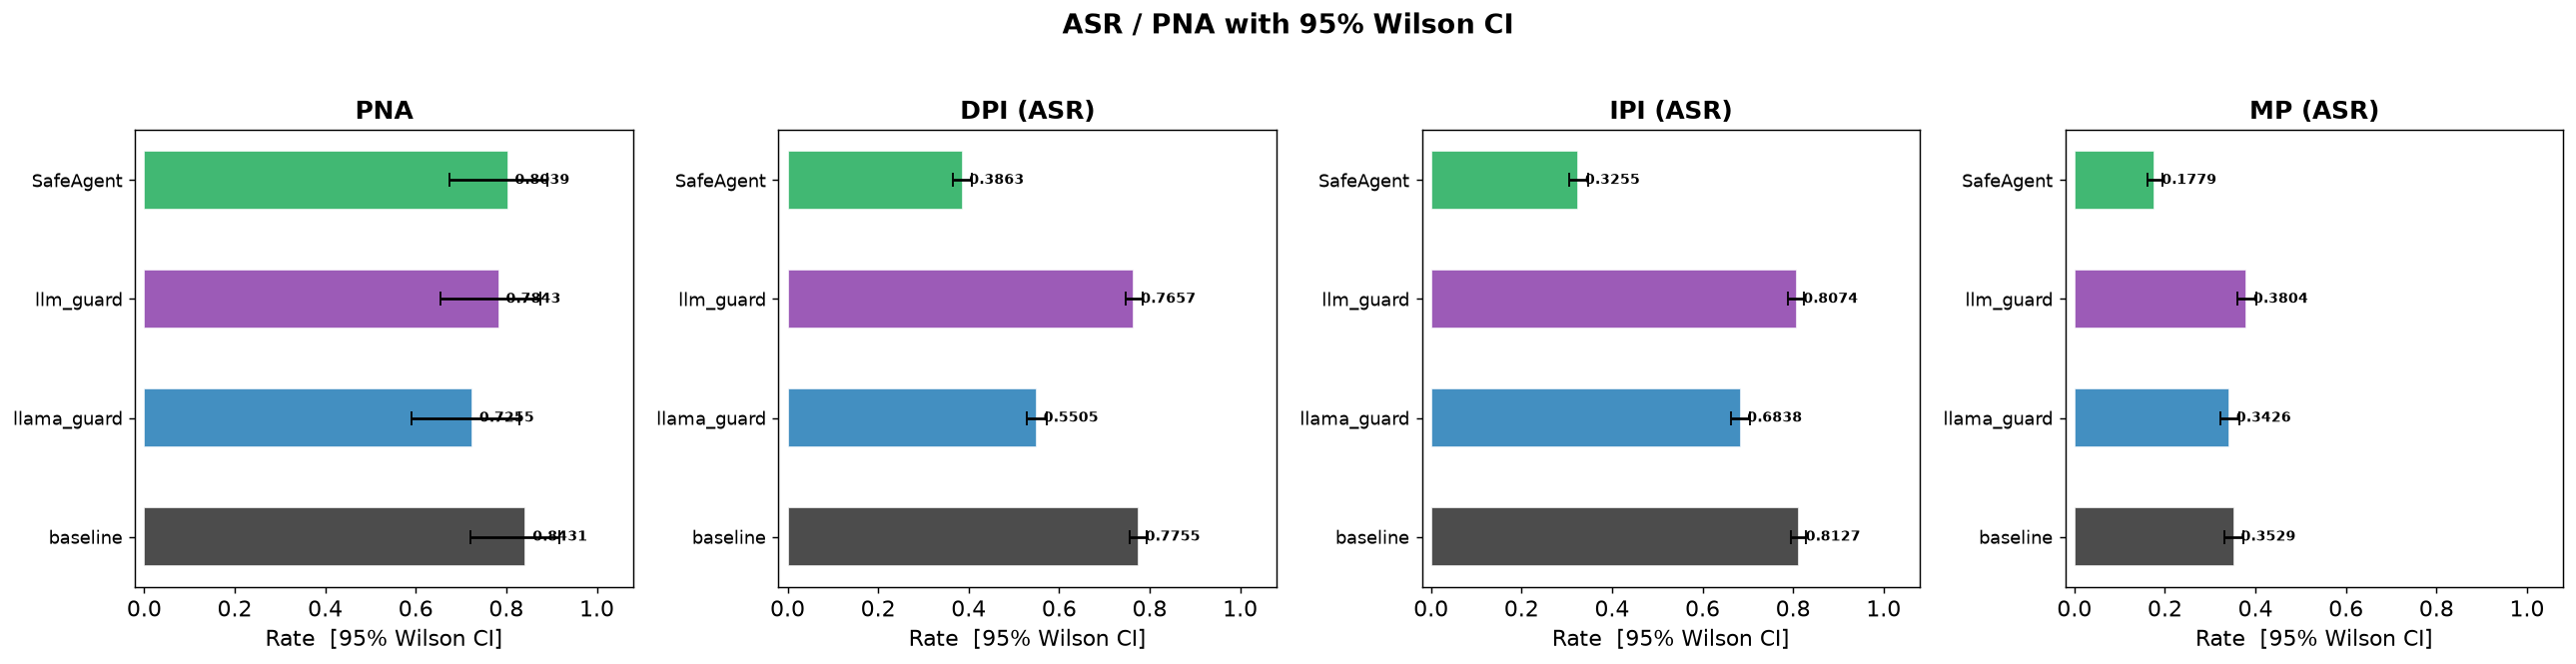

In [19]:
# ============================================================
# Grouped bar chart with Wilson CI error bars
# ============================================================
DEFENSE_COLORS = {
    "baseline": "#333333",
    "llama_guard": "#2980b9",
    "llm_guard": "#8e44ad",
    "SafeAgent": "#27ae60",
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, sc, label in zip(axes, COL_ORDER, COL_LABELS):
    sub = stats[stats['scenario'] == sc].set_index('defense')
    vals = sub.loc[DEFENSES, 'rate'].values
    lo = sub.loc[DEFENSES, 'CI_lower'].values
    hi = sub.loc[DEFENSES, 'CI_upper'].values
    y = np.arange(len(DEFENSES))

    colours = [DEFENSE_COLORS[d] for d in DEFENSES]
    err_l = vals - lo
    err_u = hi - vals

    bars = ax.barh(y, vals, height=0.5, xerr=(err_l, err_u),
                   color=colours, edgecolor='white', capsize=4, alpha=0.88)
    ax.set_yticks(y)
    ax.set_yticklabels(DEFENSES, fontsize=10)
    ax.set_xlim(-0.02, 1.08)
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_xlabel("Rate  [95% Wilson CI]")

    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 0.015, bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va='center', fontsize=8, fontweight='bold')

plt.suptitle("ASR / PNA with 95% Wilson CI", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

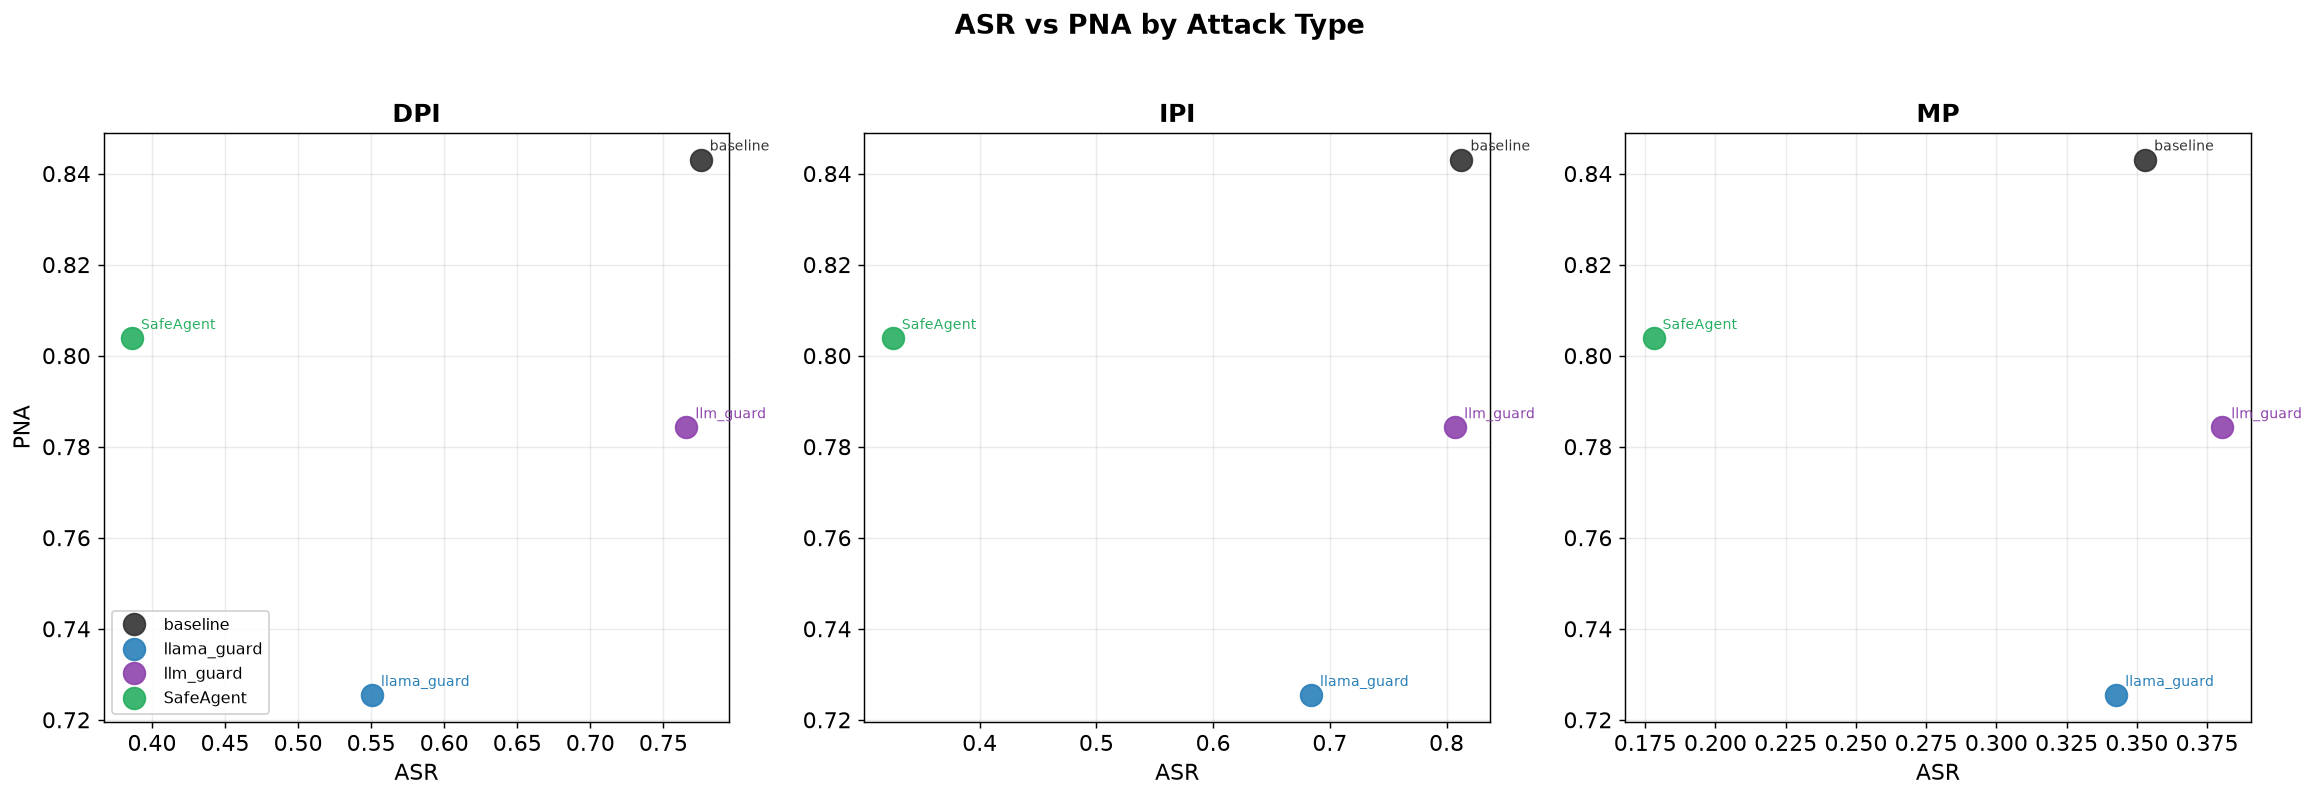

In [20]:
# ============================================================
# Three-panel Pareto scatter: ASR vs PNA
# ============================================================
pna_rates = stats[stats['scenario'] == 'benign'].set_index('defense')['rate']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, attack in zip(axes, ["DPI", "IPI", "MP"]):
    asr_sub = stats[stats['scenario'] == attack].set_index('defense')

    for d in DEFENSES:
        x = asr_sub.loc[d, 'rate']
        y = pna_rates.get(d, 0)
        colour = DEFENSE_COLORS[d]
        ax.plot(x, y, 'o', color=colour, markersize=12, alpha=0.9,
                label=d if attack == 'DPI' else "")
        ax.annotate(d, (x, y), xytext=(5, 5),
                    textcoords='offset points', fontsize=8, color=colour)

    ax.set_xlabel("ASR")
    ax.set_ylabel("PNA" if attack == 'DPI' else "")
    ax.set_title(attack, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.25)
    if attack == 'DPI':
        ax.legend(framealpha=0.85, fontsize=9, loc='lower left')

plt.suptitle("ASR vs PNA by Attack Type", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# Paired Bootstrap & Exact McNemar — utilities
# ============================================================
from scipy.stats import binom

COMPARISONS = [
    ("SafeAgent", "baseline"),
    ("SafeAgent", "llama_guard"),
    ("SafeAgent", "llm_guard"),
]
B = 20000
ALPHA = 0.05

def paired_bootstrap(diffs, n_resamples=B, alpha=ALPHA, seed=42):
    rng = np.random.default_rng(seed)
    n = len(diffs)
    means = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        means[i] = np.mean(diffs[idx])
    lo, hi = np.percentile(means, [alpha/2*100, (1-alpha/2)*100])
    return float(np.mean(diffs)), float(lo), float(hi)

def exact_mcnemar(sv, ov):
    a = int(np.sum((sv == 1) & (ov == 1)))
    b = int(np.sum((sv == 1) & (ov == 0)))
    c = int(np.sum((sv == 0) & (ov == 1)))
    d = int(np.sum((sv == 0) & (ov == 0)))
    nd = b + c
    if nd == 0:
        return {'a': a, 'b': b, 'c': c, 'd': d, 'p_value': 1.0, 'significant': False}
    k = min(b, c)
    p = min(2.0 * binom.cdf(k, nd, 0.5), 1.0)
    return {'a': a, 'b': b, 'c': c, 'd': d,
            'odds_ratio': b/c if c > 0 else float('inf'),
            'p_value': p, 'significant': p < ALPHA}

def holm_bonferroni(p_values):
    m = len(p_values)
    sorted_idx = np.argsort(p_values)
    sorted_p = np.array(p_values)[sorted_idx]
    adj = np.ones(m)
    for rank, idx in enumerate(sorted_idx):
        adj[idx] = min(float(sorted_p[rank]) * (m - rank), 1.0)
    return adj, adj < ALPHA

def load_aligned(a_name, b_name, scenario):
    """Align two defenses' CSVs on (agent_name, task, attacker_idx)."""
    col = "task_ok" if scenario == "benign" else "attack_ok"
    a = pd.read_csv(DATA_ROOT / a_name / f"{scenario}.csv")
    b = pd.read_csv(DATA_ROOT / b_name / f"{scenario}.csv")
    a = a[a['status']=='ok'].reset_index(drop=True)
    b = b[b['status']=='ok'].reset_index(drop=True)
    m = a[[col,'agent_name','task','attacker_idx']].merge(
        b[[col,'agent_name','task','attacker_idx']],
        on=['agent_name','task','attacker_idx'], suffixes=('_a','_b'))
    va = m[f'{col}_a'].values
    vb = m[f'{col}_b'].values
    # Flip attack metrics: 1 = desirable outcome (defence success)
    if scenario != "benign":
        va = 1 - va
        vb = 1 - vb
    return va, vb, len(m)

print("Utilities loaded")

Utilities loaded


In [22]:
# ============================================================
# Paired Bootstrap — all 12 comparisons
# ============================================================
boot_rows = []
for a_name, b_name in COMPARISONS:
    for sc in SCENARIOS:
        va, vb, n = load_aligned(a_name, b_name, sc)
        metric = "PNA" if sc == "benign" else "ASR"
        safe_rate = float(va.mean())
        other_rate = float(vb.mean())
        diff_m, lo, hi = paired_bootstrap(va - vb)
        boot_rows.append({
            'comparison': f'{a_name} vs {b_name}',
            'scenario': sc, 'metric': metric, 'N': n,
            'SafeAgent': safe_rate,
            'Other': other_rate,
            'diff': diff_m,
            'CI_lo': lo, 'CI_hi': hi,
            'sig': (lo > 0) or (hi < 0),
            'display': f"{diff_m:+.4f} [{lo:+.4f}, {hi:+.4f}]",
        })

df_boot = pd.DataFrame(boot_rows)
print(f"Bootstrap: {len(df_boot)} rows")

Bootstrap: 12 rows


In [23]:
# ============================================================
# Exact McNemar — all 12 comparisons + Holm correction
# ============================================================
mc_rows = []
for a_name, b_name in COMPARISONS:
    for sc in SCENARIOS:
        va, vb, n = load_aligned(a_name, b_name, sc)
        m = exact_mcnemar(va, vb)
        metric = "PNA" if sc == "benign" else "ASR"
        mc_rows.append({
            'comparison': f'{a_name} vs {b_name}',
            'scenario': sc, 'metric': metric, 'N': n,
            'SafeAgent only success': m['b'],
            'Other only success': m['c'],
            'odds_ratio': m['odds_ratio'],
            'p_value': m['p_value'],
            'significant': m['significant'],
        })

df_mc = pd.DataFrame(mc_rows)

# Holm-Bonferroni correction across all 12 comparisons
p_vals = df_mc["p_value"].values
adj_p, adj_sig = holm_bonferroni(p_vals)
df_mc["p_holm"] = adj_p
df_mc["significant_holm"] = adj_sig
print(f"McNemar: {len(df_mc)} rows, Holm-adjusted p-values added")

McNemar: 12 rows, Holm-adjusted p-values added


In [24]:
# ============================================================
# Display: Paired Bootstrap
# ============================================================
print("=" * 85)
print("Paired Bootstrap 95% CI  (SafeAgent minus Other)")
print("=" * 85)
display(df_boot[[
    'comparison', 'scenario', 'N', 'Δ Success Rate', 'CI_lo', 'CI_hi', 'sig'
]] if 'Δ Success Rate' in df_boot.columns else df_boot)

print()
print("=" * 85)
print("Exact McNemar Test (Holm-corrected p-values)")
print("=" * 85)
for comp in ['SafeAgent vs baseline', 'SafeAgent vs llama_guard', 'SafeAgent vs llm_guard']:
    sub = df_mc[df_mc['comparison'] == comp].copy()
    print(f"\n--- {comp} ---")
    display(sub[[
        'scenario', 'N',
        'SafeAgent only success', 'Other only success',
        'odds_ratio', 'p_holm', 'significant_holm'
    ]].style.format({
        'p_holm': lambda v: '<0.001' if v < 0.001 else f'{v:.4f}',
        'odds_ratio': '{:.4f}',
    }))

Paired Bootstrap 95% CI  (SafeAgent minus Other)


,comparison,scenario,metric,N,SafeAgent,Other,diff,CI_lo,CI_hi,sig,display
0,SafeAgent vs baseline,benign,PNA,51,0.803922,0.843137,-0.039216,-0.117647,0.039216,False,"-0.0392 [-0.1176, +0.0392]"
1,SafeAgent vs baseline,DPI,ASR,2040,0.613725,0.224510,0.389216,0.365686,0.413235,True,"+0.3892 [+0.3657, +0.4132]"
2,SafeAgent vs baseline,IPI,ASR,2040,0.674510,0.187255,0.487255,0.464216,0.510294,True,"+0.4873 [+0.4642, +0.5103]"
3,SafeAgent vs baseline,MP,ASR,2040,0.822059,0.647059,0.175000,0.153431,0.196078,True,"+0.1750 [+0.1534, +0.1961]"
4,SafeAgent vs llama_guard,benign,PNA,51,0.803922,0.725490,0.078431,-0.058824,0.215686,False,"+0.0784 [-0.0588, +0.2157]"
5,SafeAgent vs llama_guard,DPI,ASR,2040,0.613725,0.449510,0.164216,0.136765,0.191667,True,"+0.1642 [+0.1368, +0.1917]"
6,SafeAgent vs llama_guard,IPI,ASR,2040,0.674510,0.316176,0.358333,0.331863,0.384804,True,"+0.3583 [+0.3319, +0.3848]"
7,SafeAgent vs llama_guard,MP,ASR,2040,0.822059,0.657353,0.164706,0.142647,0.187255,True,"+0.1647 [+0.1426, +0.1873]"
8,SafeAgent vs llm_guard,benign,PNA,51,0.803922,0.784314,0.019608,-0.078431,0.117647,False,"+0.0196 [-0.0784, +0.1176]"
9,SafeAgent vs llm_guard,DPI,ASR,2040,0.613725,0.234314,0.379412,0.355882,0.403431,True,"+0.3794 [+0.3559, +0.4034]"



Exact McNemar Test (Holm-corrected p-values)

--- SafeAgent vs baseline ---


,scenario,N,SafeAgent only success,Other only success,odds_ratio,p_holm,significant_holm
0,benign,51,1,3,0.3333,1.0000,False
1,DPI,2040,855,61,14.0164,<0.001,True
2,IPI,2040,1027,33,31.1212,<0.001,True
3,MP,2040,457,100,4.5700,<0.001,True



--- SafeAgent vs llama_guard ---


,scenario,N,SafeAgent only success,Other only success,odds_ratio,p_holm,significant_holm
4,benign,51,8,4,2.0000,1.0000,False
5,DPI,2040,601,266,2.2594,<0.001,True
6,IPI,2040,870,139,6.2590,<0.001,True
7,MP,2040,458,122,3.7541,<0.001,True



--- SafeAgent vs llm_guard ---


,scenario,N,SafeAgent only success,Other only success,odds_ratio,p_holm,significant_holm
8,benign,51,4,3,1.3333,1.0000,False
9,DPI,2040,847,73,11.6027,<0.001,True
10,IPI,2040,1032,49,21.0612,<0.001,True
11,MP,2040,511,98,5.2143,<0.001,True


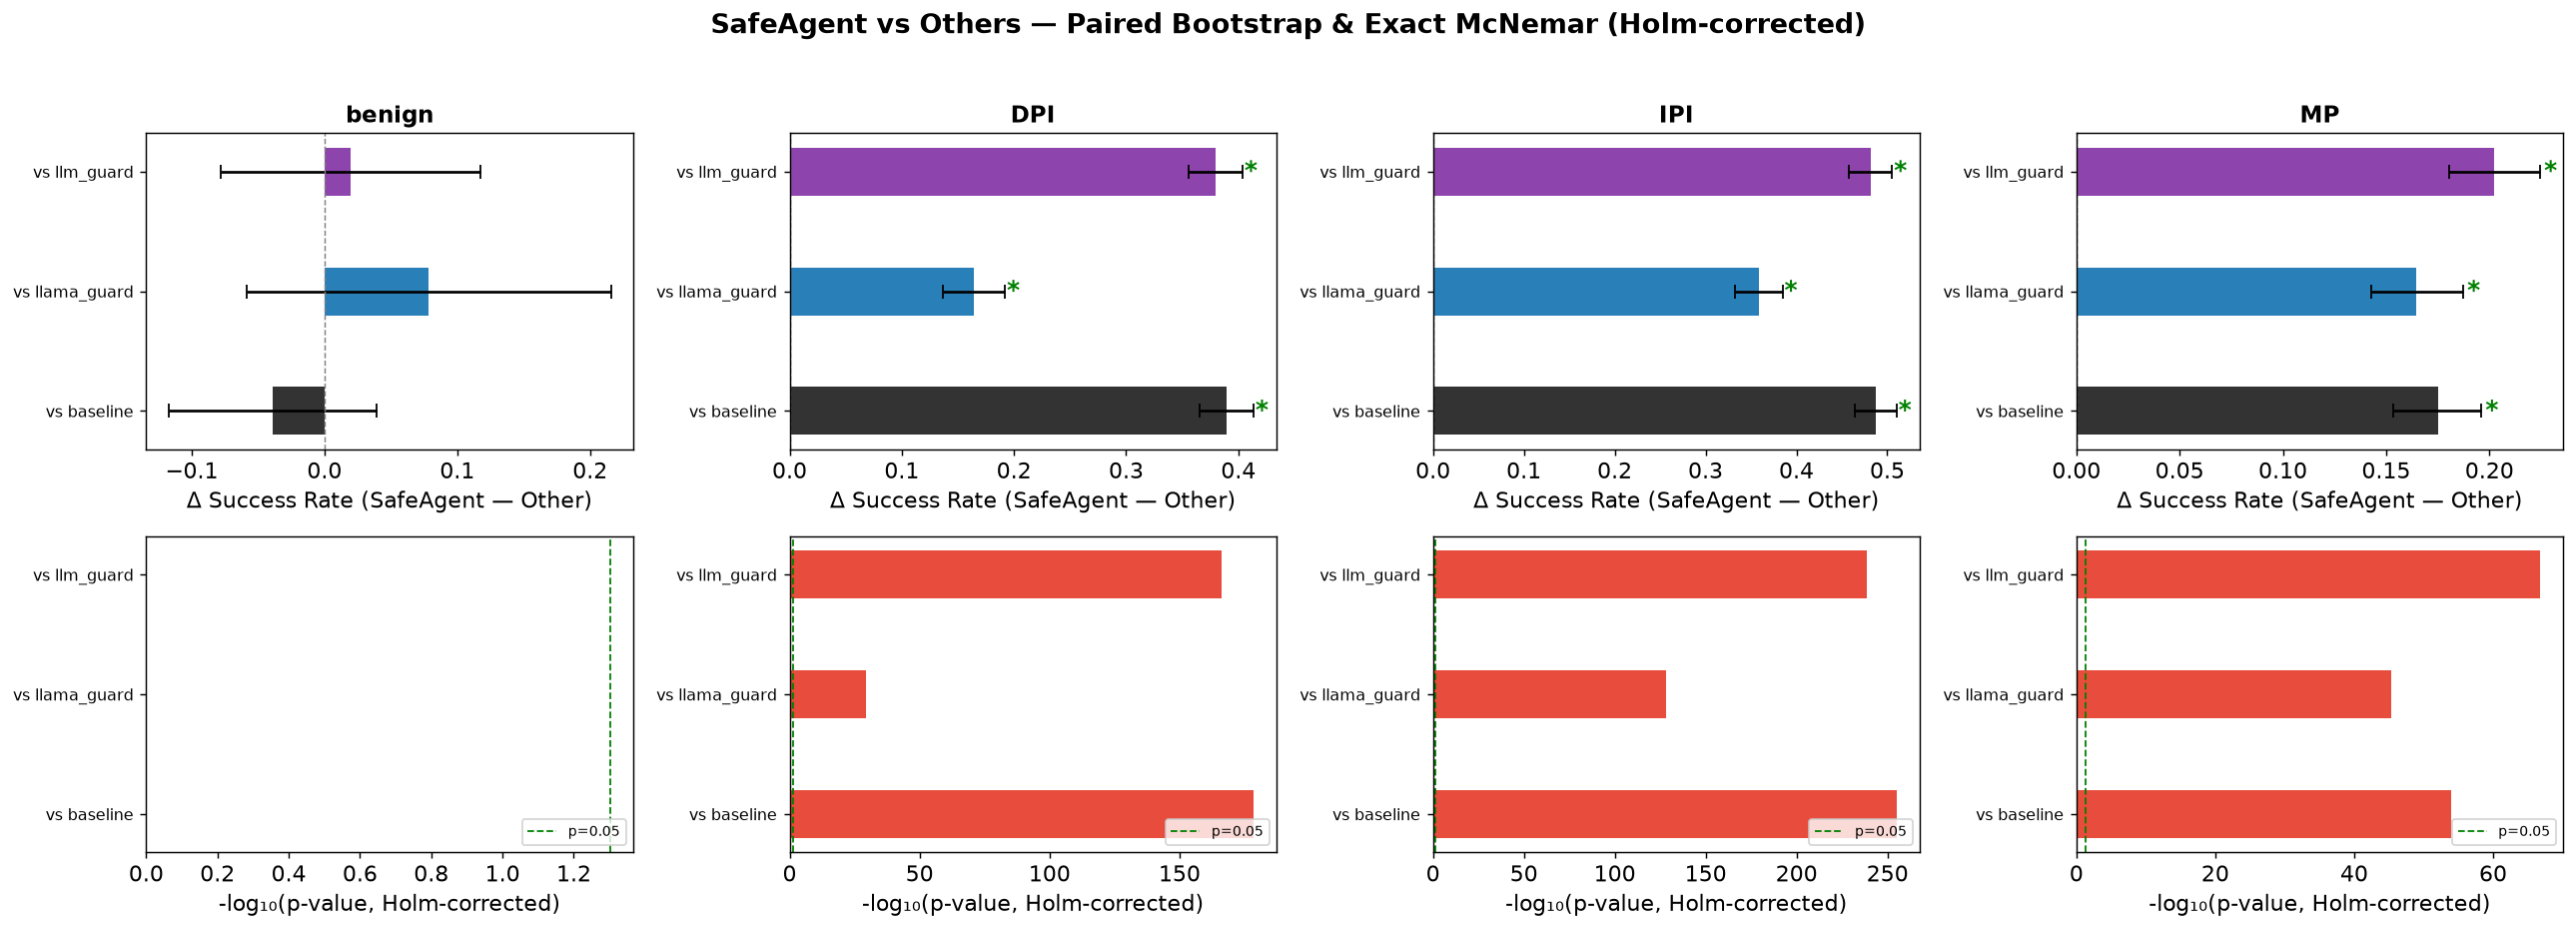

In [25]:
# ============================================================
# Visualisation: Bootstrap diff + McNemar -log10(p)
# ============================================================
COMP_LABELS = {
    'SafeAgent vs baseline': 'vs baseline',
    'SafeAgent vs llama_guard': 'vs llama_guard',
    'SafeAgent vs llm_guard': 'vs llm_guard',
}
COMP_COLORS = {
    'SafeAgent vs baseline': '#333333',
    'SafeAgent vs llama_guard': '#2980b9',
    'SafeAgent vs llm_guard': '#8e44ad',
}

fig, axes = plt.subplots(2, 4, figsize=(20, 7))

for i, scenario in enumerate(SCENARIOS):
    # Upper: Bootstrap diff
    ax = axes[0, i]
    sub = df_boot[df_boot['scenario'] == scenario]
    y = np.arange(len(sub))
    colours = [COMP_COLORS[c] for c in sub['comparison']]
    err_l = sub['diff'].values - sub['CI_lo'].values
    err_u = sub['CI_hi'].values - sub['diff'].values

    ax.barh(y, sub['diff'].values, 0.4, color=colours,
            xerr=(err_l, err_u), capsize=4)
    ax.axvline(0, color='grey', ls='--', lw=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels([COMP_LABELS[c] for c in sub['comparison']], fontsize=9)
    ax.set_title(scenario, fontsize=13, fontweight='bold')
    ax.set_xlabel('Δ Success Rate (SafeAgent — Other)')

    for j, (_, r) in enumerate(sub.iterrows()):
        if r['sig']:
            ax.text(r['CI_hi'] + 0.002, j, '*', fontsize=14, va='center', fontweight='bold', color='green')

    # Lower: McNemar -log10(p_holm)
    ax = axes[1, i]
    sub_m = df_mc[df_mc['scenario'] == scenario]
    neg_log_p = -np.log10(sub_m['p_holm'].values + 1e-300)
    colours_m = ['#e74c3c' if s else '#95a5a6' for s in sub_m['significant_holm']]

    ax.barh(np.arange(len(sub_m)), neg_log_p, 0.4, color=colours_m)
    ax.axvline(-np.log10(ALPHA), color='green', ls='--', lw=1, label=f'p={ALPHA}')
    ax.set_yticks(np.arange(len(sub_m)))
    ax.set_yticklabels([COMP_LABELS[c] for c in sub_m['comparison']], fontsize=9)
    ax.set_xlabel('-log₁₀(p-value, Holm-corrected)')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('SafeAgent vs Others — Paired Bootstrap & Exact McNemar (Holm-corrected)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# Export summary CSV
# ============================================================
OUTPUT_DIR = Path("../outputs/main_result/ASB")
stats.to_csv(OUTPUT_DIR / "asr_pna_summary.csv", index=False)
pivot.to_csv(OUTPUT_DIR / "asr_pna_summary_pivot.csv")
df_boot.to_csv(OUTPUT_DIR / "paired_bootstrap_results.csv", index=False)
df_mc.to_csv(OUTPUT_DIR / "mcnemar_results.csv", index=False)
print("All CSVs saved to", OUTPUT_DIR)

All CSVs saved to ../outputs/main_result/ASB
